In [1]:
from utils import *
#import episcanpy.api as epi
import time
import umap

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

# Read data

In [11]:
#atac = sc.read_h5ad("../../h5ad_files/c_atac_spatial_peaks.h5ad")
#expr = sc.read_h5ad("../../h5ad_files/c_sp_trans_wide_ad.h5ad")

In [13]:
'''
sc.pp.normalize_total(expr, target_sum=1e4)
sc.pp.log1p(expr)

#count_mat = atac.X.todense().T
count_mat = atac.X.T
tf_mat = 1.0 * count_mat / np.tile(np.sum(count_mat,axis=0), (count_mat.shape[0],1))
ATAC_count = np.log(1 + np.multiply(1e4*tf_mat,  np.tile((1.0 * count_mat.shape[1] / np.sum(count_mat,axis=1)).reshape(-1,1), (1,count_mat.shape[1]))))
atac.X = scipy.sparse.csc_matrix(ATAC_count.T)

atac, expr
'''

(AnnData object with n_obs × n_vars = 5274 × 381274
     obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density'
     var: 'chrom', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
     uns: 'files', 'gearyC', 'spatial_neighbors'
     obsm: 'spatial'
     obsp: 'spatial_connectivities', 'spatial_distances',
 AnnData object with n_obs × n_vars = 5274 × 18931
     obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density'

In [14]:
#atac.write_h5ad("desc_normalized_atac_peaks.h5ad")

In [15]:
#expr.write_h5ad("desc_normalized_rna.h5ad")

In [2]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [91]:
#filtered_atac = atac[:, atac.var['n_cells_by_counts'] > 10].copy()

In [18]:
#atac = filtered_atac

In [3]:
atac = atac[:, atac.var['n_cells_by_counts'] > 10].copy()

In [92]:
np.all(atac.obs_names == expr.obs_names)

True

# Run Descart

In [12]:
save_path = 'result/first_descart_test'
if not os.path.exists(save_path):
    os.makedirs(save_path)
seed_base = 1
tf = None
pc = 10
k = 20
similarity = 'cosine'
iter_time = 4
spmethod = 'threshold'
neighbor = 5
sp_dist = 'recip'
pre_select = 'highest'
peaks_num = 50000
distance = 'euclidean'
r = 0.4

num_select_peak = 20000
idx_atac, _, _, _, _, _,_, _ = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

num_select_peak = 2000
idx_expr, _, _, _, _, _,_, _ = run_descart(expr, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

idx_atac.shape, idx_expr.shape

AnnData object with n_obs × n_vars = 5274 × 72148
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density'
    var: 'chrom', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
    uns: 'files', 'gearyC', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'
(5274, 72148)
(5274, 5274)
(5274, 10)
0.0
compute scores


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


scores:
[10381.67698569 10381.83837457 10381.84887288 ... 30398.77234864
 32907.71986117 36544.23274335]
(5274, 5274)
(5274, 10)
0.0
compute scores


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


scores:
[10651.42340756 10651.56254579 10651.57174099 ... 30298.30556817
 32899.69374962 36348.98906701]
(5274, 5274)
(5274, 10)
0.0
compute scores


...

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


scores:
[18855.09726804 18856.00782139 18857.6736226  ... 56134.28424043
 56555.10361375 56766.94302558]
(5274, 5274)
(5274, 10)
0.0
compute scores


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


scores:
[18855.09702524 18856.0077192  18857.67335112 ... 56134.28412813
 56555.1033815  56766.9432403 ]


((20000,), (2000,))

In [13]:
idx_atac, idx_expr

(array([65324, 24000, 52417, ..., 46390, 26010, 71830]),
 array([13881, 16527, 11934, ..., 13744, 13992,  4232]))

In [81]:
expr[:, 13881].var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,is_training
ptgs1,37,0.01154,0.011474,98.876404,38,3.663562,37,False,0.009383,0.569499,0.347026,False


In [78]:
atac[:, 65324].var

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr17:80982326-80982825,chr17,80982326,80982825,40,0.013362,98.785302,44.0,40,False


# Gene-peak interaction detection

In [14]:
'''

file_path = '../data/'
dataset = 'E13_5-S1'
atac = sc.read_h5ad(file_path + dataset + '_atac' + '.h5ad')
atac.X = scipy.sparse.csc_matrix(atac.X)
atac.obs['label'] = atac.obs['Annotation_for_Combined']
 
expr = sc.read_h5ad(file_path + dataset + '_expr' + '.h5ad')
expr.X = scipy.sparse.csc_matrix(expr.X)
expr.obs['label'] = expr.obs['Annotation_for_Combined']
expr.var_names_make_unique()

barcode_set1 = set(atac.obs_names)
barcode_set2 = set(expr.obs_names)

common_barcodes = barcode_set1.intersection(barcode_set2)

atac = atac[atac.obs_names.isin(common_barcodes), :]
expr = expr[expr.obs_names.isin(common_barcodes), :]
expr = expr[atac.obs_names]

'''

atac_20000 = atac[:,idx_atac]
expr_2000 = expr[:,idx_expr]
atac_20000,expr_2000

(View of AnnData object with n_obs × n_vars = 5274 × 20000
     obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density'
     var: 'chrom', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
     uns: 'files', 'gearyC', 'spatial_neighbors'
     obsm: 'spatial'
     obsp: 'spatial_connectivities', 'spatial_distances',
 View of AnnData object with n_obs × n_vars = 5274 × 2000
     obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'un

In [15]:
sc.pp.normalize_total(expr_2000, target_sum=10000)
sc.pp.log1p(expr_2000)
sc.pp.scale(expr_2000)
expr_2000

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 5274 × 2000
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density', 'squidpy_domains', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'is_training', 'mean', 'std'
    uns: 'gearyC', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'overlap_genes', 'pca', 'spatial_neighbors', 'squidpy_domains_colors', 'subclass_colors', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'tangram_ct_pred'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [16]:
count_mat = atac_20000.X.toarray().T

In [32]:
tf_mat = 1.0 * count_mat / np.tile(np.sum(count_mat,axis=0), (count_mat.shape[0],1))

In [35]:
tf_mat

array([[5.13047735e-06, 1.63918681e-04, 1.17623749e-04, ...,
        3.79290486e-06, 9.58908458e-06, 2.01420989e-04],
       [2.79415544e-05, 1.55613907e-05, 6.45894534e-06, ...,
        2.49404620e-05, 1.56179085e-04, 6.33911486e-06],
       [4.82287260e-06, 2.53335802e-05, 4.33110608e-06, ...,
        1.24078906e-05, 1.45388794e-05, 7.60211151e-06],
       ...,
       [2.49703480e-05, 7.21056931e-05, 2.37881846e-04, ...,
        1.45733153e-04, 2.70304045e-05, 1.07100950e-05],
       [6.63423361e-06, 5.78454528e-05, 3.84036757e-05, ...,
        2.05790086e-04, 1.32546236e-04, 8.17071577e-06],
       [1.32772868e-04, 1.32692527e-04, 1.32319619e-04, ...,
        1.58012263e-04, 1.27478314e-04, 1.04910105e-04]], dtype=float32)

In [36]:
ATAC_count = np.log(1 + np.multiply(1e4*tf_mat,  np.tile((1.0 * count_mat.shape[1] / np.sum(count_mat,axis=1)).reshape(-1,1), (1,count_mat.shape[1]))))

In [38]:
atac_20000.X = scipy.sparse.csc_matrix(ATAC_count.T)

In [43]:
adata = anndata.concat([atac_20000, expr_2000], axis=1)
adata.obs['label'] = list(atac_20000.obs['label'])
adata.obsm['spatial'] = atac_20000.obsm['spatial']
adata

AnnData object with n_obs × n_vars = 5274 × 22000
    obs: 'label'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
    obsm: 'spatial'

In [48]:
adata.X = scipy.sparse.csc_matrix(adata.X)

ATAC_count_test = scale(adata.X.toarray())
count = ATAC_count_test.copy()
print(count.shape)
    
similarity_matrix_acb = np.zeros([count.shape[0], count.shape[0]])
similarity_matrix_spatial = np.zeros([count.shape[0], count.shape[0]])

distance_matrix = np.zeros([count.shape[0], count.shape[0]])
print(distance_matrix.shape)

count = PCA(n_components=pc,random_state=int(seed_base*1000)).fit_transform(count)
print(count.shape)
if similarity == 'Jaccard':
    if distance == 'euclidean':
        diff = count[:, np.newaxis, :] - count[np.newaxis, :, :]
        distance_matrix = np.linalg.norm(diff, axis=2)
        np.fill_diagonal(distance_matrix, np.inf)
    elif distance == 'cosine':
        count_norm = np.linalg.norm(count, axis=1, keepdims=True)
        dot_product_matrix = np.dot(count, count.T)
        distance_matrix = 1 - dot_product_matrix / (count_norm * count_norm.T)
        np.fill_diagonal(distance_matrix, np.inf)

distance_matrix_acb = np.copy(distance_matrix)

spatial_data = adata.obsm['spatial']
diff = spatial_data[:, np.newaxis, :] - spatial_data[np.newaxis, :, :]
distance_matrix = np.linalg.norm(diff, axis=2)
np.fill_diagonal(distance_matrix, np.inf)
distance_matrix_spatial = np.copy(distance_matrix)

similarity_matrix_acb = np.zeros([count.shape[0], count.shape[0]])
similarity_matrix_spatial = np.zeros([count.shape[0], count.shape[0]])
if spmethod == 'threshold':
    min_dist = np.min(distance_matrix_spatial)
    if sp_dist == 'const':
        similarity_matrix_spatial = np.array(distance_matrix_spatial <= neighbor * min_dist,dtype=int)
    elif sp_dist == 'recip':
        similarity_matrix_spatial = min_dist / distance_matrix_spatial
        similarity_matrix_spatial = similarity_matrix_spatial * (distance_matrix_spatial <= neighbor * min_dist)
    else:
        similarity_matrix_spatial = (min_dist / distance_matrix_spatial)**2
        similarity_matrix_spatial = similarity_matrix_spatial * (distance_matrix_spatial <= neighbor * min_dist)

elif spmethod == 'SNN':
    neighbor_index = np.argsort(distance_matrix_spatial, axis=1)[:,0:k]
    if similarity == "Jaccard":
        for i in range(count.shape[0]):
            for j in range(i):
                intersect_num = len(np.intersect1d(neighbor_index[i,:], neighbor_index[j,:]))
                similarity_matrix_spatial[i][j] = 1.0*intersect_num/(2*k-intersect_num)
                similarity_matrix_spatial[j][i] = 1.0*intersect_num/(2*k-intersect_num)
if similarity == "Jaccard":
    neighbor_index = np.argsort(distance_matrix_acb, axis=1)[:,0:k]
    for i in range(count.shape[0]):
        for j in range(i):
            intersect_num = len(np.intersect1d(neighbor_index[i,:], neighbor_index[j,:]))
            similarity_matrix_acb[i][j] = 1.0*intersect_num/(2*k-intersect_num)
            similarity_matrix_acb[j][i] = 1.0*intersect_num/(2*k-intersect_num)
elif similarity == "cosine":
    similarity_matrix_acb = sklearn.metrics.pairwise.cosine_similarity(count)
    for i in range(count.shape[0]):
        similarity_matrix_acb[i][i] = -float('inf')
    neighbor_index = np.argsort(similarity_matrix_acb, axis=1)[:,0:(count.shape[0]-k)]
    for i in range(count.shape[0]):
        similarity_matrix_acb[i,neighbor_index[i,:]] = 0
    print(similarity_matrix_acb[0,0])

similarity_matrix = (1 - r) * similarity_matrix_acb + r*similarity_matrix_spatial


print('compute scores')
scores = np.zeros(adata.n_vars)
X_processed = ATAC_count_test

temp_matrix = np.matmul(similarity_matrix, X_processed)
scores = np.sum(X_processed * temp_matrix, axis=0)
sorted_index = np.argsort(scores)
idx = sorted_index[::-1]
print('scores:')
print(scores[idx])

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


(5274, 22000)
(5274, 5274)
(5274, 10)
0.0
compute scores
scores:
[56975.81940622 56042.15734737 55336.75538405 ...  5481.12710212
  4796.43605854  4657.92425029]


In [49]:
start_time = time.time()
pdist_ = peak_modules_(selected_peaks_data=X_processed, similarity_matrix=similarity_matrix, method='complete')
pdist_ = (pdist_+pdist_.T)/2
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")
print("Peak modules calculation has been done.")

pdist_.shape

Running time: 36.722819 seconds
Peak modules calculation has been done.


(22000, 22000)

In [50]:
pdist

<function scipy.spatial.distance.pdist(X, metric='euclidean', *, out=None, **kwargs)>

In [51]:
g_p_similarity = pdist_[20000:,:20000]

In [71]:
g_p_similarity[second_index]

74450.81858211831

## The most likely gene and peak

In [56]:
index = np.unravel_index(np.argmax(g_p_similarity, axis=None), g_p_similarity.shape)
index

(1935, 19998)

In [61]:
expr_2000[:,1935].var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,is_training,mean,std
gramd3,124,0.048284,0.047155,96.234437,159,5.075174,123,True,0.057365,1.155377,1.361016,False,0.632511,0.596935


In [62]:
atac_20000[:,19998].var

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr6:85906858-85907357,chr6,85906858,85907357,16,0.004859,99.514121,16.0,16,False


gramd3

chr6:85906858-85907357

In [69]:
# Find the index of the second largest value in the flattened array
# np.argsort(g_p_similarity, axis=None) returns the indices that would sort the flattened array.
# [-2] gets the second-to-last index, which corresponds to the second largest value's position
second_max_flat_index = np.argsort(g_p_similarity, axis=None)[-2]

# Convert the flat index to multi-dimensional indices using the original shape
second_index = np.unravel_index(second_max_flat_index, g_p_similarity.shape)

print(f"The indices of the largest entry are: {index}")
print(f"The indices of the second largest entry are: {second_index}")

The indices of the largest entry are: (1935, 19998)
The indices of the second largest entry are: (1667, 19998)


In [72]:
expr_2000[:,1667].var

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,is_training,mean,std
csrp1,85,0.02976,0.029326,97.418767,98,4.59512,85,True,0.037922,1.444277,1.861021,False,0.480593,0.524611


In [74]:
atac_20000[:,19998].var

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr6:85906858-85907357,chr6,85906858,85907357,16,0.004859,99.514121,16.0,16,False


### examining rorb

In [166]:
gene_name = "rorb"
gene_idx = list(expr_2000.var_names).index(gene_name)

In [167]:
peak_scores = g_p_similarity[gene_idx, :]

In [168]:
top_peak_indices = np.argsort(peak_scores)[::-1]  # descending order
top_peaks = top_peak_indices[:100]  # get top 10 correlated peaks

In [169]:
atac_20000.var.iloc[top_peaks]

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr7:97718977-97719476,chr7,97718977,97719476,13,0.003948,99.605223,13.0,13,False
chr5:40402601-40403100,chr5,40402601,40403100,12,0.003948,99.635591,13.0,11,False
chr13:28713251-28713750,chr13,28713251,28713750,11,0.003340,99.665958,11.0,11,False
chr4:141623576-141624075,chr4,141623576,141624075,11,0.003340,99.665958,11.0,11,False
chr4:65833161-65833660,chr4,65833161,65833660,13,0.003948,99.605223,13.0,13,False
...,...,...,...,...,...,...,...,...,...
chr7:105572869-105573368,chr7,105572869,105573368,11,0.003340,99.665958,11.0,11,False
chr13:106689064-106689563,chr13,106689064,106689563,13,0.003948,99.605223,13.0,12,False
chr13:73426632-73427131,chr13,73426632,73427131,12,0.003644,99.635591,12.0,12,False
chr1:173973057-173973556,chr1,173973057,173973556,11,0.003340,99.665958,11.0,11,False


In [170]:
# Get top 100 correlated peaks for robustness
top_peaks_chr19 = atac_20000.var.iloc[top_peaks]
chr19_peaks = top_peaks_chr19[top_peaks_chr19['chrom'] == 'chr19']

In [171]:
chr19_peaks

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr19:18972253-18972752,chr19,18972253,18972752,11,0.003340,99.665958,11.0,11,False
chr19:28679927-28680426,chr19,28679927,28680426,14,0.004251,99.574856,14.0,14,False


In [172]:
positions_in_top_peaks = [i for i, idx in enumerate(top_peaks_chr19.index) if idx in chr19_peaks.index]

In [173]:
positions_in_top_peaks

[68, 89]

In [174]:
18907969-18972752

-64783

In [175]:
tox_gene_name = "tox"
tox_gene_idx = list(expr_2000.var_names).index(tox_gene_name)

In [176]:
tox_peak_scores = g_p_similarity[tox_gene_idx, :]

In [177]:
tox_peak_indices = np.argsort(tox_peak_scores)[::-1]  # descending order
tox_peaks = tox_peak_indices[:100]  # get top 10 correlated peaks

In [178]:
atac_20000.var.iloc[tox_peaks]

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr2:20324860-20325359,chr2,20324860,20325359,13,0.003948,99.605223,13.0,12,False
chr9:40505492-40505991,chr9,40505492,40505991,15,0.004555,99.544488,15.0,15,False
chr7:45167090-45167589,chr7,45167090,45167589,14,0.004251,99.574856,14.0,14,False
chr5:42238836-42239335,chr5,42238836,42239335,20,0.006073,99.392651,20.0,20,False
chr11:66674435-66674934,chr11,66674435,66674934,20,0.006073,99.392651,20.0,20,False
...,...,...,...,...,...,...,...,...,...
chr9:93992220-93992719,chr9,93992220,93992719,25,0.007592,99.240814,25.0,25,False
chr14:52003234-52003733,chr14,52003234,52003733,11,0.003340,99.665958,11.0,11,False
chr12:25189208-25189707,chr12,25189208,25189707,22,0.006681,99.331916,22.0,22,False
chr5:7918141-7918640,chr5,7918141,7918640,19,0.005770,99.423019,19.0,19,False


In [179]:
# Get top 100 correlated peaks for robustness
tox_peaks_chr4 = atac_20000.var.iloc[tox_peaks]
chr4_peaks = tox_peaks_chr4[tox_peaks_chr4['chrom'] == 'chr4']

In [181]:
chr4_peaks

,chrom,start,end,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,is_training
chr4:141865001-141865500,chr4,141865001,141865500,12,0.003644,99.635591,12.0,12,False
chr4:47440904-47441403,chr4,47440904,47441403,12,0.003644,99.635591,12.0,12,False


In [188]:
tox_positions_in_top_peaks = [i for i, idx in enumerate(tox_peaks_chr4.index) if idx in chr4_peaks.index]

In [189]:
tox_positions_in_top_peaks

[11, 90]

In [192]:
6686353-141865001

-135178648

In [161]:
g_p_similarity[gene_idx, top_peaks]

array([32094.32136673, 30329.15994038, 30208.41628743, 30089.96306003,
       29711.44711348, 28909.66022126, 28566.91937707, 28403.04845935,
       27673.19255991, 27528.93380783])

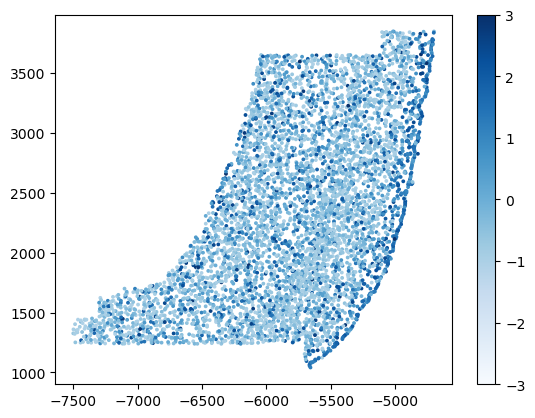

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


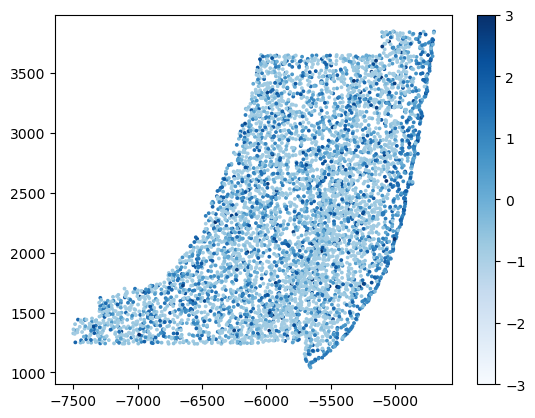

In [57]:
accs = expr_2000.X[:,index[0]]
coord_x = np.array(atac_20000.obsm['spatial'][:,0])
coord_y = np.array(atac_20000.obsm['spatial'][:,1])
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()

accs = scale(atac_20000.X.toarray())[:,index[1]]
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()

## Gene to peak

In [84]:
expr_matrix = expr_2000.X
atac_matrix = scale(atac_20000.X.toarray())
expr_matrix.shape, atac_matrix.shape

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


((5274, 2000), (5274, 20000))

In [85]:
a = anndata.AnnData(scipy.sparse.csc_matrix(atac_matrix))
a.obs_names = list(atac.obs_names)
a.obs['label'] = list(atac.obs['label'])
a.obsm['spatial'] = atac.obsm['spatial']

b = anndata.AnnData(scipy.sparse.csc_matrix(expr_matrix))
b.obs_names = list(expr.obs_names)
b.obs['label'] = list(expr.obs['label'])
b.obsm['spatial'] = expr.obsm['spatial']

result = np.zeros_like(g_p_similarity)
for col in range(g_p_similarity.shape[1]):
    indices = np.argpartition(g_p_similarity[:, col], -20)[-20:]
    result[indices, col] = g_p_similarity[indices, col]
    
    indices = np.argpartition(g_p_similarity[:, col],5)[:5]
    result[indices, col] = g_p_similarity[indices, col]
result.shape

(2000, 20000)

In [86]:
atac_matrix_pred = expr_matrix @ result
atac_matrix_pred = scale(atac_matrix_pred)
atac_matrix_pred.shape

(5274, 20000)

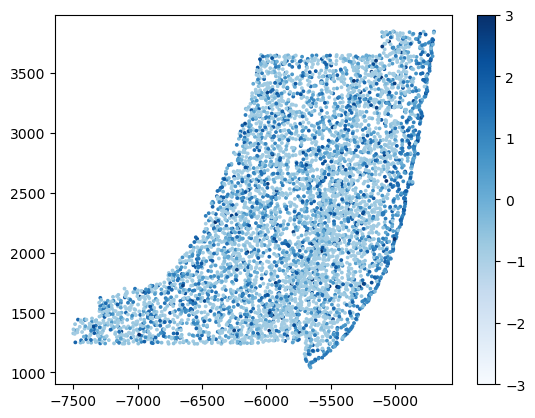

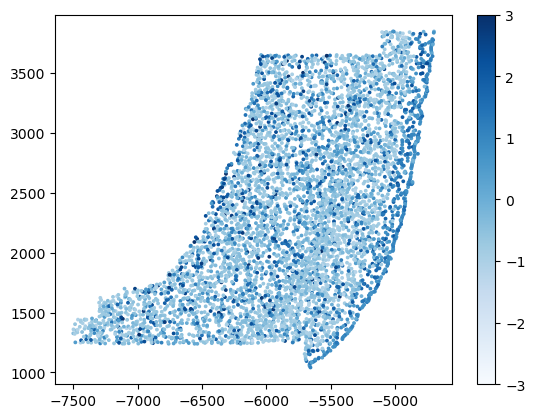

In [87]:
accs = atac_matrix[:,19998]
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()

accs = atac_matrix_pred[:,19998]
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()

## Peak to gene

In [88]:
g_p_similarity_T = g_p_similarity.T
result = np.zeros_like(g_p_similarity_T)
for col in range(g_p_similarity_T.shape[1]):
    indices = np.argpartition(g_p_similarity_T[:, col], -20)[-20:]
    result[indices, col] = g_p_similarity_T[indices, col]
    
    indices = np.argpartition(g_p_similarity_T[:, col],5)[:5]
    result[indices, col] = g_p_similarity_T[indices, col]
result.shape

(20000, 2000)

In [89]:
expr_matrix_pred = atac_matrix @ result
expr_matrix_pred = scale(expr_matrix_pred)
expr_matrix_pred.shape

(5274, 2000)

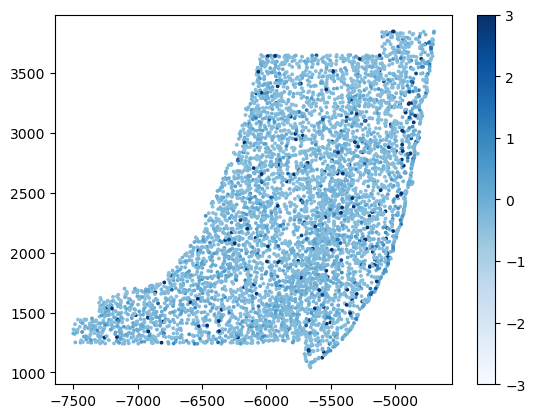

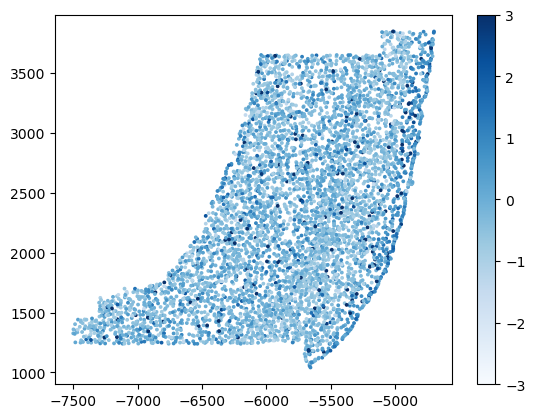

In [90]:
accs = expr_matrix[:,1999]
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()

accs = expr_matrix_pred[:,1999]
accs = np.array(accs)
accs = np.squeeze(accs)
plt.scatter(coord_x, coord_y, c=accs, s=3, cmap='Blues',vmin=-3, vmax=3)
plt.colorbar()
plt.show()